In [58]:
import sys
print(sys.executable)

/usr/bin/python3


In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
import re
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

In [60]:
from google.colab import drive
drive.mount('/content/drive')

df1 = pd.read_csv('/content/drive/MyDrive/Electric_Vehicle_Population_Data.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [61]:
df1 = pd.read_csv('/content/drive/MyDrive/Electric_Vehicle_Population_Data.csv')

In [62]:
df1.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,JN1AZ0CP5C,Stevens,Colville,WA,99114.0,2012,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73.0,7.0,153331706,POINT (-117.90454 48.54657),AVISTA CORP,5.306595e+10
1,JTMABABA7P,Yakima,Yakima,WA,98903.0,2023,SUBARU,SOLTERRA,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,15.0,253586308,POINT (-120.71847 46.55029),PACIFICORP,5.307700e+10
2,1N4AZ1CP1J,King,Seattle,WA,98122.0,2018,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,151.0,37.0,333135022,POINT (-122.31009 47.60803),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,5UX43EU09S,Kitsap,Poulsbo,WA,98370.0,2025,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,40.0,23.0,267525737,POINT (-122.64681 47.73689),PUGET SOUND ENERGY INC,5.303594e+10
4,3C3CFFGE5F,Thurston,Yelm,WA,98597.0,2015,FIAT,500,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,87.0,2.0,474468501,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10


In [63]:
df1.isnull().sum().sort_values(ascending=False)

,0
Legislative District,700
Vehicle Location,109
County,24
City,24
2020 Census Tract,24
Electric Utility,24
Postal Code,24
Electric Range,11
Model,0
Make,0


In [64]:
# Country, City, 2020 Census Tract, Electric Utility sütunlarının Nan dəyər sayı eyni olduğu üçün onların üst üstə düşməsini yoxlayaq
sutunlar = ['County', 'City', 'Postal Code', 'Electric Utility', '2020 Census Tract']

for col in sutunlar:
    result = (df1['County'].isnull() == df1[col].isnull()).all()
    print(f"County vs {col}: {result}")

County vs County: True
County vs City: True
County vs Postal Code: True
County vs Electric Utility: True
County vs 2020 Census Tract: True


In [65]:
# Nan dəyər sayı ümumi data sayına görə çox az olduğu üçük silək, çünki bu bizim gələcək addımlarımıza təsir etməyəcək
cols = ['Legislative District', 'Vehicle Location', 'Electric Range']
df1 = df1.dropna(subset=cols)

In [66]:
df1.isnull().sum().sort_values(ascending=False)

,0
VIN (1-10),0
County,0
City,0
State,0
Postal Code,0
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0


In [67]:
df1.duplicated().sum()

np.int64(0)

In [68]:
# Qeyd edilən sütunlar datasetin həcmini atırır bu da əməliyyatlar zamanı sürəti zəiflədir, vaxtı uzadır. Ona görə silək.
df1 = df1.drop(columns=['VIN (1-10)', 'State', 'Postal Code', 'DOL Vehicle ID'])


In [69]:
# df1-i df-ə çevirək
df = df1.copy()

In [70]:
#  Model Year və Electric Range sütunlarının statistikası (Digər numeric sütunlar kod və s olduğu üçün onlara baxmaq məqsədəuyğun deyil)
print("Model Year və Electric Range statistikası:")
print(df[['Model Year', 'Electric Range']].describe())

# Categoric sütunların unikal dəyər sayı
print("\nCategoric sütunların unikal dəyər sayı:")
Categoric_sutunlar = ['County', 'City', 'State', 'Make', 'Model',
                        'Electric Vehicle Type',
                        'Clean Alternative Fuel Vehicle (CAFV) Eligibility',
                        'Electric Utility']

for col in Categoric_sutunlar:
    if col in df.columns:
        print(f"{col}: {df[col].nunique()} dənə")

Model Year və Electric Range statistikası:
          Model Year  Electric Range
count  278984.000000   278984.000000
mean     2022.074563       39.175394
std         3.060823       78.225007
min      1999.000000        0.000000
25%      2021.000000        0.000000
50%      2023.000000        0.000000
75%      2024.000000       32.000000
max      2027.000000      337.000000

Categoric sütunların unikal dəyər sayı:
County: 39 dənə
City: 495 dənə
Make: 47 dənə
Model: 187 dənə
Electric Vehicle Type: 2 dənə
Clean Alternative Fuel Vehicle (CAFV) Eligibility: 3 dənə
Electric Utility: 76 dənə


In [71]:
# Ən çox rast gəlinən avtomobil markaları
print("\nƏn çox rast gəlinən 20 avtomobil markası:")
print(df['Make'].value_counts().head(20))

# Model Year üzrə avtomobil sayı
print("\nİl üzrə avtomobil sayı:")
print(df['Model Year'].value_counts().sort_index())

# Ən çox avtomobil olan şəhərlər
print("\nƏn çox avtomobil olan 20 şəhər:")
print(df['City'].value_counts().head(20))


Ən çox rast gəlinən 20 avtomobil markası:
Make
TESLA            114468
CHEVROLET         19217
NISSAN            16140
FORD              15296
KIA               13919
TOYOTA            11789
BMW               11582
HYUNDAI           10332
RIVIAN             8842
VOLKSWAGEN         7420
VOLVO              7332
JEEP               6892
AUDI               5930
CHRYSLER           3881
MERCEDES-BENZ      3327
HONDA              3090
SUBARU             2713
CADILLAC           2425
PORSCHE            2002
POLESTAR           1607
Name: count, dtype: int64

İl üzrə avtomobil sayı:
Model Year
1999        2
2000        7
2002        1
2003        1
2008       19
2010       21
2011      577
2012     1369
2013     3947
2014     3207
2015     4399
2016     5084
2017     8443
2018    14083
2019    10830
2020    12046
2021    20870
2022    29888
2023    60054
2024    49784
2025    36961
2026    17389
2027        2
Name: count, dtype: int64

Ən çox avtomobil olan 20 şəhər:
City
Seattle          43248
B

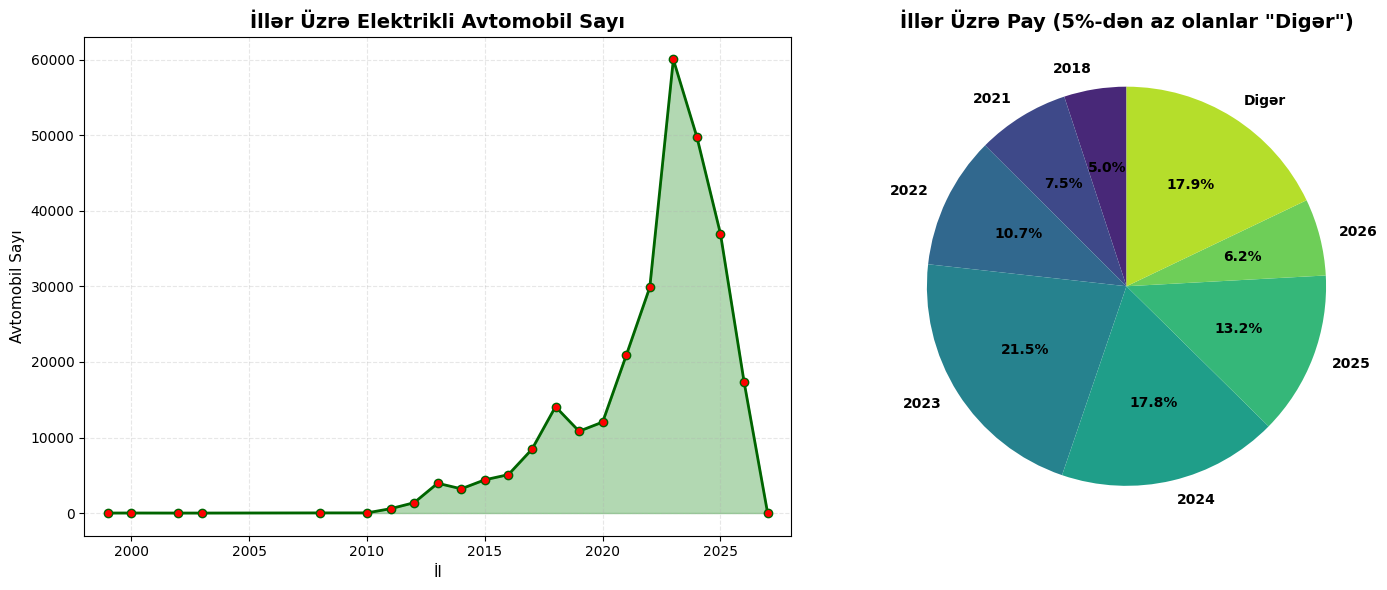

In [72]:
# Figure və axes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Sol qrafik: İllər üzrə avtomobil sayı
year_counts = df['Model Year'].value_counts().sort_index()
ax1.plot(year_counts.index, year_counts.values, marker='o', linewidth=2,
         markersize=6, color='darkgreen', markerfacecolor='red')
ax1.fill_between(year_counts.index, year_counts.values, alpha=0.3, color='green')

ax1.set_title('İllər Üzrə Elektrikli Avtomobil Sayı', fontsize=14, fontweight='bold')
ax1.set_xlabel('İl', fontsize=11)
ax1.set_ylabel('Avtomobil Sayı', fontsize=11)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(year_counts.index.min() - 1, year_counts.index.max() + 1)

# Bütün illər üzrə pay (daha yığcam)
# Statistikaya baxanda elektrik avtomobillərinin sayı son illər artmışdır. Buna görə də son illərin sayını əsas götürək
all_years = year_counts
colors = sns.color_palette('viridis', n_colors=len(all_years))

# 5%-dən az olanları "Digər" kimi birləşdir
threshold = 5
other_sum = all_years[all_years / all_years.sum() * 100 < threshold].sum()
main_years = all_years[all_years / all_years.sum() * 100 >= threshold]

if other_sum > 0:
    main_years['Digər'] = other_sum

colors = sns.color_palette('viridis', n_colors=len(main_years))
wedges, texts, autotexts = ax2.pie(main_years.values, labels=main_years.index,
                                     autopct='%1.1f%%', colors=colors,
                                     textprops={'fontsize': 10, 'fontweight': 'bold'},
                                     startangle=90)

ax2.set_title('İllər Üzrə Pay (5%-dən az olanlar "Digər")', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [73]:
# Elektriklə işləyən avtomobillərin növləri
df['Electric Vehicle Type'].value_counts()

,count
Electric Vehicle Type,
Battery Electric Vehicle (BEV),223278
Plug-in Hybrid Electric Vehicle (PHEV),55706


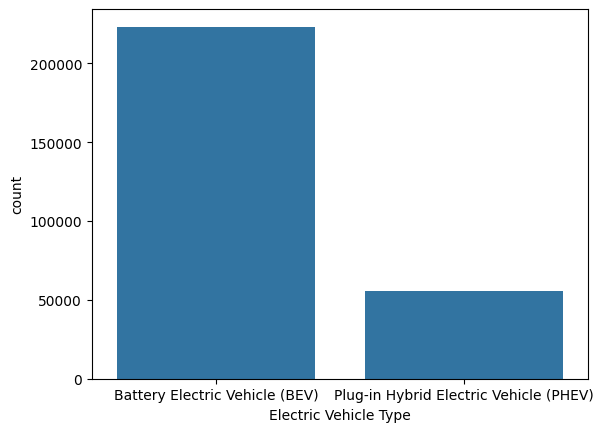

In [74]:
sns.countplot(x='Electric Vehicle Type', data=df)
plt.show()

In [75]:
df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].value_counts()

,count
Clean Alternative Fuel Vehicle (CAFV) Eligibility,
Eligibility unknown as battery range has not been researched,177443
Clean Alternative Fuel Vehicle Eligible,77288
Not eligible due to low battery range,24253


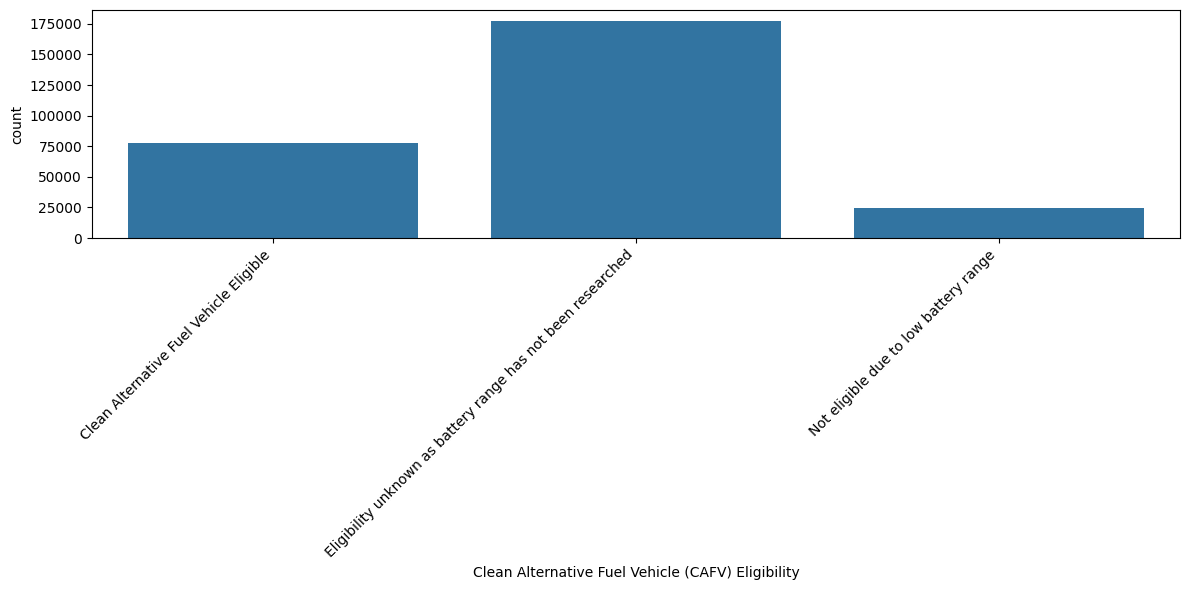

In [76]:
plt.figure(figsize=(12, 6))
sns.countplot(x='Clean Alternative Fuel Vehicle (CAFV) Eligibility', data=df)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

İki dəyişən arasında əlaqə

In [77]:
# TESLA-nın CAFV dəyərləri üzrə sayı
tesla_cafv = df[df['Make'] == 'TESLA']['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].value_counts()
print("TESLA-nın CAFV Eligibility dəyərləri üzrə sayı:")
print(tesla_cafv)

# Faizlə göstərmək üçün
print("TESLA-nın CAFV Eligibility faiz paylanması:")
print((tesla_cafv / tesla_cafv.sum() * 100).round(1))

TESLA-nın CAFV Eligibility dəyərləri üzrə sayı:
Clean Alternative Fuel Vehicle (CAFV) Eligibility
Eligibility unknown as battery range has not been researched    90121
Clean Alternative Fuel Vehicle Eligible                         24347
Name: count, dtype: int64
TESLA-nın CAFV Eligibility faiz paylanması:
Clean Alternative Fuel Vehicle (CAFV) Eligibility
Eligibility unknown as battery range has not been researched    78.7
Clean Alternative Fuel Vehicle Eligible                         21.3
Name: count, dtype: float64


In [78]:
# Tesla avtomobili elektrikli avtomobil olduğu üçün 'Clean Alternative Fuel Vehicle (CAFV) Eligibility' sütununda tesla avtomobillərinin qarşısında olan
# 'Eligibility unknown as battery range has not been researched' dəyərini 'Clean Alternative Fuel Vehicle Eligible' olaraq dəyişə bilərik. Ancaq
# ABŞ qanun vericiliyə görə avtomobillərin dövlət güzəştlərindən yararlanmaları üçün bazada həmin avtomobillər 'Clean Alternative Fuel Vehicle Eligible' kimi qeydiyyata düşməlidir.
# Bunun üçün avtomobil sahibi müraciət etməlidir deyə bizim onu dəyişməyimiz düzgün deyil.
# Bu həmçinin digər marka və modeldə olan elektrik avtomobillərin də aiddir

In [79]:
# Avtomobillərin elektriklə qət etdiyi məsafəni müəyyən etmək üçün hər marka üçün ən çox rast gəlinən Electric Range dəyəri (mod)
make_mode_range = df.groupby('Make')['Electric Range'].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None).sort_values(ascending=False)

print("Marka üzrə ən çox rast gəlinən Electric Range (mod):")
print("="*50)
for make, range_val in make_mode_range.head(20).items():
    print(f"{make}: {range_val:.0f} mil")

Marka üzrə ən çox rast gəlinən Electric Range (mod):
JAGUAR: 234 mil
WHEEGO ELECTRIC CARS: 100 mil
TH!NK: 100 mil
FIAT: 87 mil
LAND ROVER: 58 mil
SMART: 58 mil
AZURE DYNAMICS: 56 mil
TOYOTA: 42 mil
MITSUBISHI: 38 mil
LAMBORGHINI: 37 mil
LEXUS: 37 mil
ALFA ROMEO: 33 mil
DODGE: 32 mil
CHRYSLER: 32 mil
MAZDA: 26 mil
LINCOLN: 21 mil
BENTLEY: 21 mil
JEEP: 21 mil
GENESIS: 0 mil
CHEVROLET: 0 mil


In [80]:
# Hər marka üçün mod, median və ortalama
make_stats = df.groupby('Make')['Electric Range'].agg([
    ('Mod', lambda x: x.mode().iloc[0] if not x.mode().empty else None),
    ('Median', 'median'),
    ('Ortalama', 'mean'),
    ('Say', 'count')
]).round(1)

# Top 20 marka
make_stats_top = make_stats.loc[df['Make'].value_counts().head(20).index].sort_values('Say', ascending=False)

print("Top 20 Marka - Mod vs Median vs Ortalama:")
print("="*60)
print(make_stats_top)

Top 20 Marka - Mod vs Median vs Ortalama:
                Mod  Median  Ortalama     Say
Make                                         
TESLA           0.0     0.0      51.3  114468
CHEVROLET       0.0    35.0      78.1   19217
NISSAN          0.0    75.0      63.7   16140
FORD            0.0     0.0       7.1   15296
KIA             0.0     0.0      28.3   13919
TOYOTA         42.0    39.0      27.8   11789
BMW             0.0    17.0      27.0   11582
HYUNDAI         0.0     0.0      11.6   10332
RIVIAN          0.0     0.0       0.0    8842
VOLKSWAGEN      0.0     0.0      14.9    7420
VOLVO           0.0    18.0      18.0    7332
JEEP           21.0    21.0      21.6    6892
AUDI            0.0     0.0      36.8    5930
CHRYSLER       32.0    32.0      32.2    3881
MERCEDES-BENZ   0.0     0.0      16.6    3327
HONDA           0.0     0.0      13.0    3090
SUBARU          0.0     0.0       0.6    2713
CADILLAC        0.0     0.0       1.3    2425
PORSCHE         0.0    13.0      48.9 

In [81]:
# Hər marka üzrə maksimum Electric Range
max_range_by_make = df.groupby('Make')['Electric Range'].max().sort_values(ascending=False)

print("Bütün Markalar Üzrə Maksimum Electric Range:")
print("="*60)
for make, max_range in max_range_by_make.items():
    print(f"{make}: {max_range:.0f} mil")

Bütün Markalar Üzrə Maksimum Electric Range:
TESLA: 337 mil
PORSCHE: 308 mil
CHEVROLET: 259 mil
HYUNDAI: 258 mil
KIA: 239 mil
JAGUAR: 234 mil
POLESTAR: 233 mil
AUDI: 222 mil
NISSAN: 215 mil
BMW: 153 mil
VOLKSWAGEN: 125 mil
MINI: 110 mil
TOYOTA: 103 mil
FORD: 100 mil
WHEEGO ELECTRIC CARS: 100 mil
TH!NK: 100 mil
MERCEDES-BENZ: 87 mil
FIAT: 87 mil
SMART: 68 mil
MITSUBISHI: 62 mil
LAND ROVER: 60 mil
AZURE DYNAMICS: 56 mil
BENTLEY: 50 mil
HONDA: 48 mil
VOLVO: 41 mil
CADILLAC: 40 mil
LEXUS: 38 mil
LAMBORGHINI: 37 mil
CHRYSLER: 33 mil
FISKER: 33 mil
ALFA ROMEO: 33 mil
MAZDA: 32 mil
DODGE: 32 mil
LINCOLN: 28 mil
JEEP: 25 mil
SUBARU: 17 mil
GENESIS: 0 mil
ACURA: 0 mil
BRIGHTDROP: 0 mil
LUCID: 0 mil
MASERATI: 0 mil
GMC: 0 mil
MULLEN AUTOMOTIVE INC.: 0 mil
ROLLS-ROYCE: 0 mil
RIVIAN: 0 mil
RAM: 0 mil
VINFAST: 0 mil


In [82]:
# datasetdə "Elecric Range" 0 mil olan avtomobillər
markalar = ['GENESIS', 'ACURA', 'BRIGHTDROP', 'LUCID', 'MASERATI',
            'GMC', 'MULLEN AUTOMOTIVE INC.', 'ROLLS-ROYCE', 'RIVIAN',
            'RAM', 'VINFAST']

# CAFV Eligibility paylanması
for marka in markalar:
    print(f"{marka}")

    # Markaya aid məlumatlar
    marka_df = df[df['Make'] == marka]

    # Ümumi say
    print(f"Ümumi avtomobil sayı: {len(marka_df):,}")

    # Electric Range statistikası
    print(f"Electric Range:")
    print(f"  - Min: {marka_df['Electric Range'].min():.0f} mil")
    print(f"  - Maks: {marka_df['Electric Range'].max():.0f} mil")
    print(f"  - Ortalama: {marka_df['Electric Range'].mean():.1f} mil")

    # CAFV Eligibility paylanması
    cafv = marka_df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].value_counts()
    print(f"\nCAFV Eligibility:")
    for status, count in cafv.items():
        print(f"  - {status}: {count:,} ({count/len(marka_df)*100:.1f}%)")

GENESIS
Ümumi avtomobil sayı: 503
Electric Range:
  - Min: 0 mil
  - Maks: 0 mil
  - Ortalama: 0.0 mil

CAFV Eligibility:
  - Eligibility unknown as battery range has not been researched: 503 (100.0%)
ACURA
Ümumi avtomobil sayı: 356
Electric Range:
  - Min: 0 mil
  - Maks: 0 mil
  - Ortalama: 0.0 mil

CAFV Eligibility:
  - Eligibility unknown as battery range has not been researched: 356 (100.0%)
BRIGHTDROP
Ümumi avtomobil sayı: 51
Electric Range:
  - Min: 0 mil
  - Maks: 0 mil
  - Ortalama: 0.0 mil

CAFV Eligibility:
  - Eligibility unknown as battery range has not been researched: 51 (100.0%)
LUCID
Ümumi avtomobil sayı: 702
Electric Range:
  - Min: 0 mil
  - Maks: 0 mil
  - Ortalama: 0.0 mil

CAFV Eligibility:
  - Eligibility unknown as battery range has not been researched: 702 (100.0%)
MASERATI
Ümumi avtomobil sayı: 1
Electric Range:
  - Min: 0 mil
  - Maks: 0 mil
  - Ortalama: 0.0 mil

CAFV Eligibility:
  - Eligibility unknown as battery range has not been researched: 1 (100.0%)
G

In [83]:
# Ən çox avtomobil sayı RIVIAN markasında olduğu üçün onun modellərinə baxaq
rivian_df = df[df['Make'] == 'RIVIAN']

print("RIVIAN avtomobilləri - Model Analizi")
# Modellər
print("\n1. Modellər:")
print(rivian_df['Model'].value_counts())

# Model və Electric Range
print("\n2. Modellər üzrə  Electric Range:")
print(rivian_df.groupby('Model')['Electric Range'].agg(['min', 'max', 'mean', 'count']).round(1))

# Model və Model Year
print("\n3. Modellər illər üzrə:")
print(rivian_df.groupby('Model')['Model Year'].value_counts().sort_index())

RIVIAN avtomobilləri - Model Analizi

1. Modellər:
Model
R1S    5140
R1T    2769
EDV     932
RCV       1
Name: count, dtype: int64

2. Modellər üzrə  Electric Range:
       min  max  mean  count
Model                       
EDV    0.0  0.0   0.0    932
R1S    0.0  0.0   0.0   5140
R1T    0.0  0.0   0.0   2769
RCV    0.0  0.0   0.0      1

3. Modellər illər üzrə:
Model  Model Year
EDV    2022           216
       2023           315
       2024           398
       2025             3
R1S    2022           182
       2023          1681
       2024           888
       2025          1783
       2026           606
R1T    2022           917
       2023           934
       2024           258
       2025           508
       2026           152
RCV    2024             1
Name: count, dtype: int64


In [84]:
# Bu markalarda avtomobil sayı az olduğu üçün tələb edilməyən avtomobil kimi qiymətləndirək və silək
silinecek = ['GENESIS', 'ACURA', 'BRIGHTDROP', 'LUCID', 'MASERATI',
             'GMC', 'MULLEN AUTOMOTIVE INC.', 'ROLLS-ROYCE', 'RAM', 'VINFAST']

print(f"Əvvəl: {len(df)}")
df = df[~df['Make'].isin(silinecek)]
print(f"Sonra: {len(df)}")

Əvvəl: 278984
Sonra: 276801


In [85]:
# RIVIAN modelləri barəsində araşdırma apardıqdan sonra onlar üçün "Electric Range" dəyərlərini təyin edək və 0-ları əvəzləyək
rivian_range = {
    'R1S': 350,
    'R1T': 350,
    'EDV': 150,
    'RCV': 200
}

# RIVIAN modelləri üçün dəyərləri yenilə
for model, range_val in rivian_range.items():
    df.loc[(df['Make'] == 'RIVIAN') & (df['Model'] == model), 'Electric Range'] = range_val

# Yoxlayaq
print(df[df['Make'] == 'RIVIAN'][['Model', 'Electric Range']].drop_duplicates())

       Model  Electric Range
283      R1T           350.0
382      R1S           350.0
20371    EDV           150.0
106621   RCV           200.0


In [86]:
# Electric Range sütununda 0 dəyərlərini markaların modellərinin maksimum dəyəri ilə əvəz edək.
# Mode da götürə bilərdik. Ona görə götürmədik ki, bəzi mode-lar 0 ola bilər və bu da bizim 0-ların sayını artıra bilər
df['Electric Range'] = df.groupby(['Make', 'Model'])['Electric Range'].transform(
    lambda x: x.replace(0, x.max())
)

In [87]:
# Hər marka üzrə maksimum Electric Range
max_range_by_make = df.groupby('Make')['Electric Range'].max().sort_values(ascending=False)

print("Bütün Markalar Üzrə Maksimum Electric Range:")
for make, max_range in max_range_by_make.items():
    print(f"{make}: {max_range:.0f} mil")

Bütün Markalar Üzrə Maksimum Electric Range:
RIVIAN: 350 mil
TESLA: 337 mil
PORSCHE: 308 mil
CHEVROLET: 259 mil
HYUNDAI: 258 mil
KIA: 239 mil
JAGUAR: 234 mil
POLESTAR: 233 mil
AUDI: 222 mil
NISSAN: 215 mil
BMW: 153 mil
VOLKSWAGEN: 125 mil
MINI: 110 mil
TOYOTA: 103 mil
FORD: 100 mil
TH!NK: 100 mil
WHEEGO ELECTRIC CARS: 100 mil
MERCEDES-BENZ: 87 mil
FIAT: 87 mil
SMART: 68 mil
MITSUBISHI: 62 mil
LAND ROVER: 60 mil
AZURE DYNAMICS: 56 mil
BENTLEY: 50 mil
HONDA: 48 mil
VOLVO: 41 mil
CADILLAC: 40 mil
LEXUS: 38 mil
LAMBORGHINI: 37 mil
ALFA ROMEO: 33 mil
CHRYSLER: 33 mil
FISKER: 33 mil
DODGE: 32 mil
MAZDA: 32 mil
LINCOLN: 28 mil
JEEP: 25 mil
SUBARU: 17 mil


In [88]:
df.groupby('Make')['Electric Range'].mean().sort_values(ascending=False).head(20)

,Electric Range
Make,
RIVIAN,328.901832
TESLA,283.352850
JAGUAR,234.000000
POLESTAR,192.112632
PORSCHE,155.761239
NISSAN,114.807559
CHEVROLET,111.395379
WHEEGO ELECTRIC CARS,100.000000
TH!NK,100.000000


In [89]:
# Electric Range 0 mil olan avtomobillər modellər üzrə
pd.set_option('display.max_rows', None)
df[df['Electric Range'] == 0][['Make', 'Model']].value_counts()

,,count
Make,Model,
FORD,MUSTANG MACH-E,6425
VOLKSWAGEN,ID.4,5974
HYUNDAI,IONIQ 5,5966
FORD,F-150,4087
KIA,EV6,3843
CHEVROLET,BOLT EUV,2912
SUBARU,SOLTERRA,2617
BMW,I4,2276
HONDA,PROLOGUE,2229


In [90]:
# Electric Range 0 mil olan avtomobillərin Elektriklə qət etdiyi real məsafə dəyərləri (Rəqəmlər rəsmi rəqəmlərdir).
real_range = {
    ('FORD', 'MUSTANG MACH-E'): 300,
    ('VOLKSWAGEN', 'ID.4'): 275,
    ('HYUNDAI', 'IONIQ 5'): 300,
    ('FORD', 'F-150'): 320,
    ('KIA', 'EV6'): 310,
    ('CHEVROLET', 'BOLT EUV'): 260,
    ('SUBARU', 'SOLTERRA'): 220,
    ('BMW', 'I4'): 270,
    ('HONDA', 'PROLOGUE'): 280,
    ('KIA', 'EV9'): 300,
    ('CHEVROLET', 'EQUINOX'): 280,
    ('NISSAN', 'ARIYA HATCHBACK'): 300,
    ('TESLA', 'CYBERTRUCK'): 340,
    ('TOYOTA', 'BZ4X'): 220,
    ('BMW', 'IX'): 300,
    ('CADILLAC', 'LYRIQ'): 310,
    ('CHEVROLET', 'BLAZER'): 280,
    ('VOLVO', 'XC40'): 260,
    ('AUDI', 'Q4'): 260,
    ('HYUNDAI', 'IONIQ 6'): 300,
    ('NISSAN', 'ARIYA MPV'): 280,
    ('FORD', 'TRANSIT'): 150,
    ('MERCEDES-BENZ', 'EQB-CLASS'): 250,
    ('LEXUS', 'RZ'): 220,
    ('CHEVROLET', 'SILVERADO'): 400,
    ('VOLVO', 'C40'): 270,
    ('CADILLAC', 'OPTIQ'): 300,
    ('MERCEDES-BENZ', 'EQE-CLASS SUV'): 280,
    ('AUDI', 'Q8'): 280,
    ('VOLKSWAGEN', 'ID. BUZZ'): 230,
    ('BMW', 'I5'): 290,
    ('MERCEDES-BENZ', 'EQS-CLASS SUV'): 280,
    ('VOLVO', 'EX30'): 270,
    ('MERCEDES-BENZ', 'EQS-CLASS SEDAN'): 350,
    ('TOYOTA', 'BZ'): 220,
    ('POLESTAR', 'POLESTAR 3'): 300,
    ('CADILLAC', 'VISTIQ'): 300,
    ('HYUNDAI', 'IONIQ 9'): 320,
    ('VOLVO', 'EX90'): 300,
    ('JEEP', 'WAGONEER S'): 300,
    ('MERCEDES-BENZ', 'EQE-CLASS SEDAN'): 280,
    ('AUDI', 'E-TRON GT'): 240,
    ('FISKER', 'OCEAN'): 360,
    ('DODGE', 'CHARGER'): 200,
    ('FIAT', '500E'): 140,
    ('HYUNDAI', 'IONIQ 5 N'): 280,
    ('BMW', 'I7'): 320,
    ('AUDI', 'RS E-TRON GT'): 230,
    ('VOLVO', 'EX40'): 260,
    ('AUDI', 'A6'): 280,
    ('MERCEDES-BENZ', 'G-CLASS'): 200,
    ('AUDI', 'SQ8'): 270,
    ('MERCEDES-BENZ', 'ESPRINTER'): 150,
    ('MAZDA', 'MX-30'): 100,
    ('CHEVROLET', 'BRIGHTDROP'): 250,
    ('AUDI', 'S6'): 260,
    ('POLESTAR', 'POLESTAR 4'): 320,
    ('AUDI', 'S E-TRON GT'): 230,
    ('VOLVO', 'EX30 CC'): 260,
    ('TOYOTA', 'MIRAI'): 400,
    ('CHEVROLET', 'BOLT'): 260
}

# Əvəzlənsin
for (make, model), value in real_range.items():
    df.loc[(df['Make'] == make) & (df['Model'] == model) & (df['Electric Range'] == 0), 'Electric Range'] = value

# Qalan 0 olan BEV-ləri sil
df = df[~((df['Electric Vehicle Type'] == 'Battery Electric Vehicle (BEV)') & (df['Electric Range'] == 0))]

# Yoxla
zero_bev = df[(df['Electric Vehicle Type'] == 'Battery Electric Vehicle (BEV)') & (df['Electric Range'] == 0)]
print(f"Qalan 0 BEV sayı: {len(zero_bev):,}")

Qalan 0 BEV sayı: 0


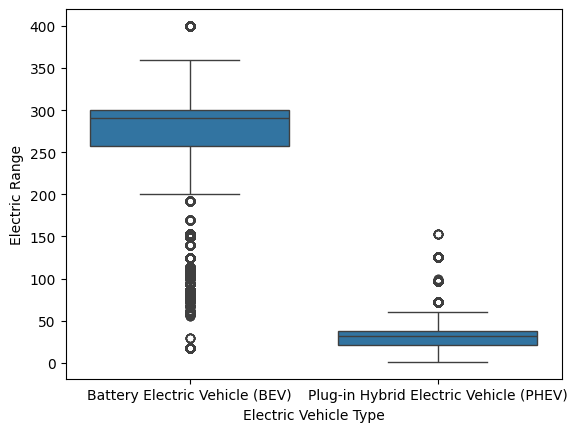

In [91]:
sns.boxplot(x='Electric Vehicle Type', y='Electric Range', data=df)
plt.show()

In [92]:
df.head()

,County,City,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,Vehicle Location,Electric Utility,2020 Census Tract
0,Stevens,Colville,2012,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73.0,7.0,POINT (-117.90454 48.54657),AVISTA CORP,5.306595e+10
1,Yakima,Yakima,2023,SUBARU,SOLTERRA,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,220.0,15.0,POINT (-120.71847 46.55029),PACIFICORP,5.307700e+10
2,King,Seattle,2018,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,151.0,37.0,POINT (-122.31009 47.60803),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,Kitsap,Poulsbo,2025,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,40.0,23.0,POINT (-122.64681 47.73689),PUGET SOUND ENERGY INC,5.303594e+10
4,Thurston,Yelm,2015,FIAT,500,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,87.0,2.0,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10


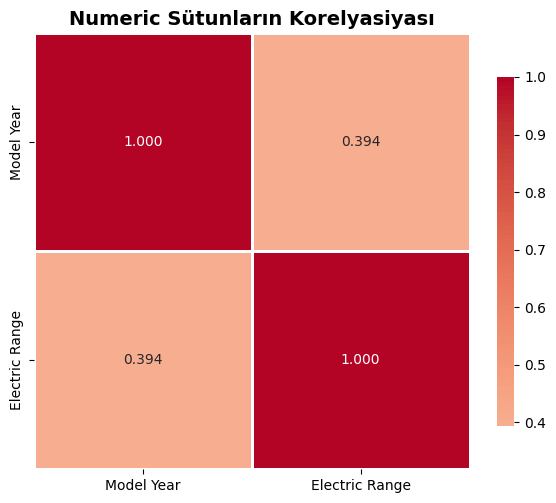

Model Year və Electric Range arasındakı korelyasiya: 0.394


In [93]:
# Numeric sütunların korelyasiyası
numeric_cols = ['Model Year', 'Electric Range']
corr_matrix = df[numeric_cols].corr()

# Heatmap
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Numeric Sütunların Korelyasiyası', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Model Year və Electric Range arasındakı korelyasiya: {corr_matrix.loc['Model Year', 'Electric Range']:.3f}")

In [94]:
from scipy.stats import chi2_contingency

# 1. Make vs Electric Vehicle Type
print("Make vs Electric Vehicle Type")
crosstab = pd.crosstab(df['Make'].head(1000), df['Electric Vehicle Type'].head(1000))
chi2, p, dof, expected = chi2_contingency(crosstab)
print(f"Chi-square: {chi2:.2f}, p-value: {p:.10f}")
print(f"Əlaqə var: {'Bəli' if p < 0.05 else 'Xeyr'}\n")

# 2. Make vs CAFV Eligibility
print("Make vs CAFV Eligibility")
crosstab2 = pd.crosstab(df['Make'].head(1000), df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].head(1000))
chi2, p, dof, expected = chi2_contingency(crosstab2)
print(f"Chi-square: {chi2:.2f}, p-value: {p:.10f}")
print(f"Əlaqə var: {'Bəli' if p < 0.05 else 'Xeyr'}\n")

# 3. Electric Vehicle Type vs CAFV Eligibility
print("Electric Vehicle Type vs CAFV Eligibility")
crosstab3 = pd.crosstab(df['Electric Vehicle Type'], df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'])
chi2, p, dof, expected = chi2_contingency(crosstab3)
print(f"Chi-square: {chi2:.2f}, p-value: {p:.10f}")
print(f"Əlaqə var: {'Bəli' if p < 0.05 else 'Xeyr'}")

Make vs Electric Vehicle Type
Chi-square: 541.98, p-value: 0.0000000000
Əlaqə var: Bəli

Make vs CAFV Eligibility
Chi-square: 634.76, p-value: 0.0000000000
Əlaqə var: Bəli

Electric Vehicle Type vs CAFV Eligibility
Chi-square: 160382.24, p-value: 0.0000000000
Əlaqə var: Bəli


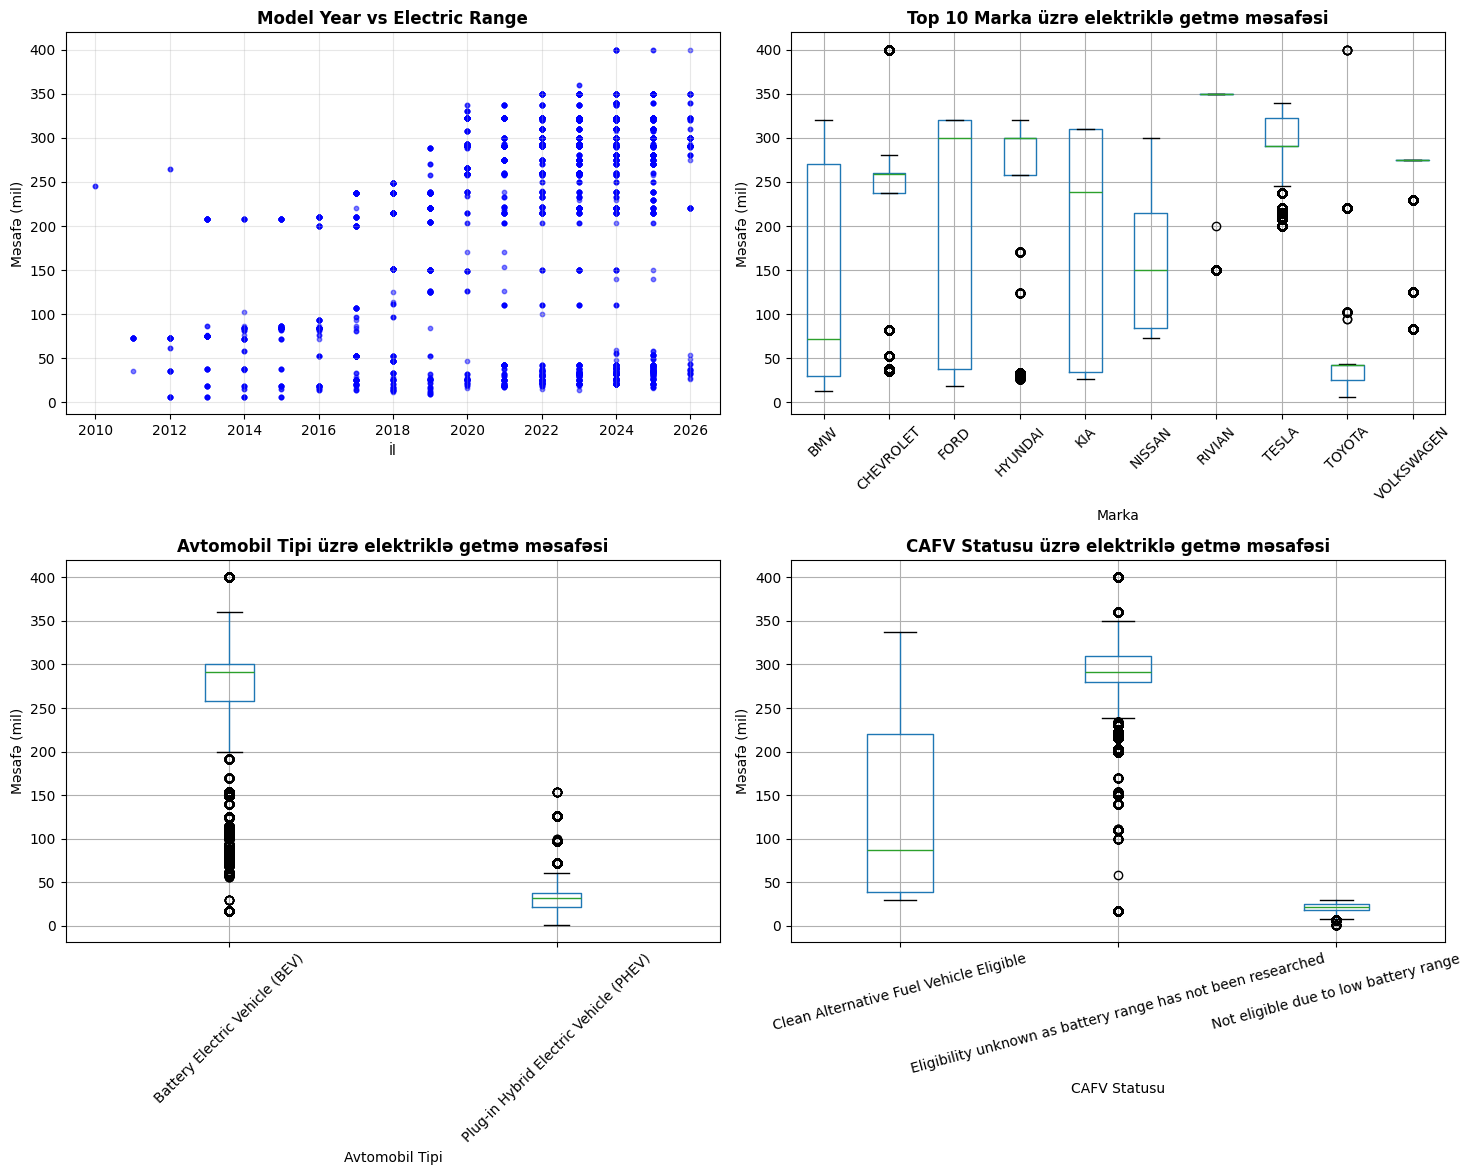

In [95]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Model Year vs Electric Range (scatter)
ax = axes[0, 0]
sample_df = df.sample(n=min(5000, len(df)))
ax.scatter(sample_df['Model Year'], sample_df['Electric Range'], alpha=0.5, s=10, c='blue')
ax.set_title('Model Year vs Electric Range', fontsize=12, fontweight='bold')
ax.set_xlabel('İl')
ax.set_ylabel('Məsafə (mil)')
ax.grid(True, alpha=0.3)

# 2. Make vs Electric Range (boxplot - top 10 marka)
ax = axes[0, 1]
top_10_makes = df['Make'].value_counts().head(10).index
df_top = df[df['Make'].isin(top_10_makes)]
df_top.boxplot(column='Electric Range', by='Make', ax=ax)
ax.set_title('Top 10 Marka üzrə elektriklə getmə məsafəsi', fontsize=12, fontweight='bold')
ax.set_xlabel('Marka')
ax.set_ylabel('Məsafə (mil)')
ax.tick_params(axis='x', rotation=45)

# 3. Electric Vehicle Type vs Electric Range (boxplot)
ax = axes[1, 0]
df.boxplot(column='Electric Range', by='Electric Vehicle Type', ax=ax)
ax.set_title('Avtomobil Tipi üzrə elektriklə getmə məsafəsi', fontsize=12, fontweight='bold')
ax.set_xlabel('Avtomobil Tipi')
ax.set_ylabel('Məsafə (mil)')
ax.tick_params(axis='x', rotation=45)

# 4. CAFV vs Electric Range (boxplot)
ax = axes[1, 1]
df.boxplot(column='Electric Range', by='Clean Alternative Fuel Vehicle (CAFV) Eligibility', ax=ax)
ax.set_title('CAFV Statusu üzrə elektriklə getmə məsafəsi', fontsize=12, fontweight='bold')
ax.set_xlabel('CAFV Statusu')
ax.set_ylabel('Məsafə (mil)')
ax.tick_params(axis='x', rotation=15)

plt.suptitle('')  # Remove default title
plt.tight_layout()
plt.show()

Xəritə üzərində real baxış

In [96]:
# Koordinatları çıxarmaq funksiyası
def extract_coordinates(location):
    if pd.isna(location):
        return None, None
    # POINT (-122.3321 47.6062) formatını çıxar
    match = re.search(r'POINT \(([-\d.]+) ([-+\d.]+)\)', str(location))
    if match:
        lon = float(match.group(1))
        lat = float(match.group(2))
        return lat, lon
    return None, None

# Koordinatları çıxarın
df['lat'] = None
df['lon'] = None
df[['lat', 'lon']] = df['Vehicle Location'].apply(lambda x: pd.Series(extract_coordinates(x)))

# Koordinatı olanları götürün
coord_df = df[df['lat'].notna()].copy()
print(f"Koordinatı olan avtomobil sayı: {len(coord_df)}")

Koordinatı olan avtomobil sayı: 276322


In [97]:
# Xəritə yaradın (mərkəz Vaşinqton ştatı üçün)
map_center = [47.5, -121.0]  # Vaşinqton ştatı mərkəzi
m = folium.Map(location=map_center, zoom_start=7, tiles='OpenStreetMap')

# İlk 1000 avtomobil üçün marker əlavə edin (çox olarsa yavaşlayar)
sample_df = coord_df.sample(n=min(1000, len(coord_df)))

for idx, row in sample_df.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=3,
        popup=f"{row['Make']} {row['Model']} ({row['Model Year']})<br>City: {row['City']}",
        color='blue',
        fill=True,
        fillOpacity=0.6
    ).add_to(m)

# Xəritəni göstərin
m

In [98]:
# Vaşinqton ştatının əsas şəhərlərinin koordinatları
city_coords = {
    'Seattle': [47.6062, -122.3321],
    'Bellevue': [47.6104, -122.2007],
    'Redmond': [47.6740, -122.1215],
    'Tacoma': [47.2529, -122.4443],
    'Spokane': [47.6588, -117.4260],
    'Vancouver': [45.6387, -122.6615],
    'Olympia': [47.0379, -122.9007],
    'Everett': [47.9789, -122.2021],
    'Renton': [47.4829, -122.2171],
    'Kent': [47.3809, -122.2348]
}

# Şəhərlər üzrə statistikalar
city_actual_counts = df['City'].value_counts().reset_index()
city_actual_counts.columns = ['City', 'Count']

# Xəritə yaradın
m_custom = folium.Map(location=[47.5, -121.0], zoom_start=7)

for city, coords in city_coords.items():
    count = city_actual_counts[city_actual_counts['City'] == city]['Count'].values
    if len(count) > 0:
        count = count[0]
        # Dairənin radiusunu avtomobil sayına görə tənzimləyin
        radius = min(count / 20, 50)  # Maksimum 50px
        folium.CircleMarker(
            location=coords,
            radius=radius,
            popup=f"{city}<br>Avtomobil sayı: {count:,}",
            color='red',
            fill=True,
            fillColor='coral',
            fillOpacity=0.6,
            tooltip=f"{city}: {count:,}"
        ).add_to(m_custom)

        # Sayını yaz
        folium.Marker(
            location=coords,
            icon=folium.DivIcon(html=f'<div style="font-size: 10px; font-weight: bold;">{count}</div>')
        ).add_to(m_custom)

m_custom

Target və Model qurulması

In [99]:
df.head()

,County,City,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,Vehicle Location,Electric Utility,2020 Census Tract,lat,lon
0,Stevens,Colville,2012,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73.0,7.0,POINT (-117.90454 48.54657),AVISTA CORP,5.306595e+10,48.54657,-117.90454
1,Yakima,Yakima,2023,SUBARU,SOLTERRA,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,220.0,15.0,POINT (-120.71847 46.55029),PACIFICORP,5.307700e+10,46.55029,-120.71847
2,King,Seattle,2018,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,151.0,37.0,POINT (-122.31009 47.60803),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10,47.60803,-122.31009
3,Kitsap,Poulsbo,2025,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,40.0,23.0,POINT (-122.64681 47.73689),PUGET SOUND ENERGY INC,5.303594e+10,47.73689,-122.64681
4,Thurston,Yelm,2015,FIAT,500,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,87.0,2.0,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10,46.94239,-122.60735


In [100]:
# FEATURE SEÇİMİ
X = df[['Model Year', 'Legislative District', '2020 Census Tract', 'lat', 'lon']]

# ENCODE
for col in X.select_dtypes(include=['object']):
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# SCALING
X_scaled = StandardScaler().fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# TARGET
y = df['Electric Vehicle Type']

# TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [101]:
# Bu featureləri ona görə seçirik ki, əvvəlki əməliyyatlarda digər featurelər data leakage yaratdı və azaltmaq üçün konkret sütunlar seçdik

In [102]:
# Klasifikasiya
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Target 1 - Train: {X_train.shape[0]:,}, Test: {X_test.shape[0]:,}")

Target 1 - Train: 221,057, Test: 55,265


In [103]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# RANDOM FOREST
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train_enc)
y_pred_rf = rf.predict(X_test)

# XGBOOST
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
xgb_model.fit(X_train, y_train_enc)
y_pred_xgb = xgb_model.predict(X_test)

# NƏTİCƏLƏR
print("RANDOM FOREST")
print(f"Accuracy: {accuracy_score(y_test_enc, y_pred_rf):.4f}")
print(classification_report(y_test_enc, y_pred_rf))

print("\nXGBOOST")
print(f"Accuracy: {accuracy_score(y_test_enc, y_pred_xgb):.4f}")
print(classification_report(y_test_enc, y_pred_xgb))

# FEATURE IMPORTANCE
rf_imp = pd.DataFrame({'feature': X.columns, 'importance': rf.feature_importances_}).sort_values('importance', ascending=False)
xgb_imp = pd.DataFrame({'feature': X.columns, 'importance': xgb_model.feature_importances_}).sort_values('importance', ascending=False)

print("\nFEATURE IMPORTANCE")
print("Random Forest:")
print(rf_imp)
print("\nXGBoost:")
print(xgb_imp)

RANDOM FOREST
Accuracy: 0.6621
              precision    recall  f1-score   support

           0       0.85      0.70      0.77     44124
           1       0.30      0.51      0.38     11141

    accuracy                           0.66     55265
   macro avg       0.58      0.61      0.57     55265
weighted avg       0.74      0.66      0.69     55265


XGBOOST
Accuracy: 0.8064
              precision    recall  f1-score   support

           0       0.81      0.99      0.89     44124
           1       0.64      0.09      0.16     11141

    accuracy                           0.81     55265
   macro avg       0.73      0.54      0.52     55265
weighted avg       0.78      0.81      0.74     55265


FEATURE IMPORTANCE
Random Forest:
                feature  importance
0            Model Year    0.445332
4                   lon    0.194729
3                   lat    0.183891
2     2020 Census Tract    0.088099
1  Legislative District    0.087949

XGBoost:
                feature  imp

In [104]:
from sklearn.model_selection import GridSearchCV

params = {'n_estimators': [100, 200], 'max_depth': [4, 6, 8], 'learning_rate': [0.05, 0.1]}
grid = GridSearchCV(xgb.XGBClassifier(random_state=42), params, cv=3, scoring='accuracy')
grid.fit(X_train, y_train_enc)
print(f"Best params: {grid.best_params_}")
print(f"Best accuracy: {grid.best_score_:.4f}")

Best params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}
Best accuracy: 0.8061


In [105]:
import joblib
joblib.dump(xgb_model, 'ev_type_model.pkl')

['ev_type_model.pkl']

# 🚗 Elektrikli Avtomobillərin Təsnifatı və Analizi

## 📌 Layihə haqqında

Bu layihədə elektrikli nəqliyyat vasitələrinin (Electric Vehicles) xüsusiyyətlərinə əsaslanaraq onların **BEV (Battery Electric Vehicle)** və **PHEV (Plug-in Hybrid Electric Vehicle)** kimi təsnifatı həyata keçirilmişdir.

Layihə yalnız model qurmaqdan ibarət deyil — burada real dünya data problemləri (çatışmayan dəyərlər, uyğunsuz məlumatlar, balanssız siniflər və s.) sistemli şəkildə analiz edilmiş və həll olunmuşdur.

---

## 🎯 Məqsəd

Layihənin əsas məqsədi:

* Elektrikli avtomobillərin tipini (BEV vs PHEV) proqnozlaşdırmaq
* Data keyfiyyətini artırmaq üçün effektiv preprocessing strategiyaları tətbiq etmək
* Data leakage və zəif feature-ları aradan qaldırmaq
* Real data üzərində etibarlı model qurmaq

---

# 🧹 Data Preprocessing və Cleaning

## 🔍 Çatışmayan dəyərlərin (NaN) analizi

Datasetdə bəzi coğrafi sütunlarda (`County`, `City`, `Postal Code`, `Electric Utility`, `2020 Census Tract`) çatışmayan dəyərlərin eyni sətirlərdə yerləşdiyi müşahidə edildi.

Bu nəticə göstərir ki:

* məlumatlar təsadüfi yox, **blok şəklində itirilib**
* bu cür məlumatlar birlikdə analiz olunmalıdır

---

## 🧹 NaN dəyərlərin idarə olunması

Model üçün kritik olan sütunlarda (`Legislative District`, `Vehicle Location`, `Electric Range`) çatışmayan dəyərlər silindi.

### Qərarın səbəbi:

* NaN sayı ümumi datasetə nisbətən çox az idi
* bu sətirlərin silinməsi model nəticəsinə ciddi təsir etmirdi
* data keyfiyyətini artırırdı

---

## ⚡ Lazımsız sütunların çıxarılması

Aşağıdakı sütunlar datasetdən çıxarıldı:

* Unikal identifikatorlar (VIN, DOL ID)
* Redundant və az faydalı sütunlar (State, Postal Code)

### Məqsəd:

* Dataset ölçüsünü azaltmaq
* Hesablama sürətini artırmaq
* Modelin yalnız faydalı məlumatlara fokuslanmasını təmin etmək

---

# 📊 Exploratory Data Analysis (EDA)

## 🔢 Statistik analiz

Əsas numeric sütunlar üzərində analiz aparıldı:

* Model Year
* Electric Range

Bu analiz vasitəsilə:

* dəyərlərin paylanması
* outlier-lar
* ümumi trendlər müəyyən edildi

---

## 📌 Kategorik dəyişənlərin analizi

Kategorik sütunlarda unikal dəyər sayı yoxlanıldı.

### Məqsəd:

* yüksək kardinalı dəyişənləri müəyyən etmək
* encoding strategiyasını planlamaq

---

## ⚠️ Domain knowledge əsaslı qərar

“CAFV Eligibility” sütunu üzrə bəzi avtomobillər üçün:

> “Eligibility unknown as battery range has not been researched”

Bu dəyərlər dəyişdirilmədi.

### Səbəb:

* bu status real dünyada dövlət qeydiyyatı ilə bağlıdır
* model üçün süni dəyişiklik etmək düzgün deyil

---

# 🚨 Data Problemləri və Həllər

## 🔻 Electric Range = 0 problemi

Bəzi avtomobillər üçün elektrik məsafəsi 0 kimi göstərilmişdir.

### Həll:

* həmin avtomobilin modeli üzrə maksimum dəyər istifadə edildi

### Məntiq:

* 0 real texniki göstərici deyil
* model səviyyəsində ən real dəyər maksimumdur

---

## 🔻 Az müşahidəli markalar

Bəzi markalarda müşahidə sayı çox az idi.

### Qərar:

* bu markalar datasetdən çıxarıldı

### Səbəb:

* modelə noise əlavə edir
* balansı pozur
* ümumiləşdirməni zəiflədir

---

# 📊 Statistik Analiz

## 🧪 Chi-Square testləri

Aşağıdakı dəyişənlər arasında əlaqə yoxlanıldı:

* Marka və avtomobil tipi
* Marka və CAFV statusu
* Avtomobil tipi və CAFV statusu

### Nəticə:

* dəyişənlər arasında statistik olaraq əhəmiyyətli əlaqə mövcuddur
* bu feature-lar model üçün informativdir

---

# 🌍 Feature Engineering

## 📍 Coğrafi məlumatların çıxarılması

“Vehicle Location” sütunundan koordinatlar (latitude və longitude) çıxarıldı.

### Əhəmiyyət:

* coğrafi məlumatlar modelə əlavə olundu
* region əsaslı analiz mümkün oldu

---

# 🧠 Model Qurulması

## 🔹 Feature Selection

Model üçün aşağıdakı əsas dəyişənlər seçildi:

* Model Year
* Legislative District
* 2020 Census Tract
* Latitude / Longitude

---

## 🔹 Data Transformasiya

* Kategorik dəyişənlər encode edildi
* Bütün dəyişənlər scale olundu

---

## 🔹 Train/Test bölünməsi

Dataset:

* 80% training
* 20% testing

Stratified bölünmə istifadə edildi ki, sinif balansı qorunsun.

---

# 🤖 Modellər

Aşağıdakı modellər sınaqdan keçirildi:

* Random Forest
* XGBoost

---

# 📊 Nəticələr

* Ən yaxşı model: **XGBoost**
* Accuracy: **~80.6%**

---

## 📈 Feature Importance

Ən vacib dəyişən:

* **Model Year (~47%)**

Digər vacib faktorlar:

* coğrafi məlumatlar
* inzibati bölgələr

---

# 📉 Problemlər və Məhdudiyyətlər

## 🔻 Class Imbalance

* PHEV sinfi zəif tanındı
* Recall ≈ 9%

---

## 🔻 Feature çatışmazlığı

* Batareya ölçüsü yoxdur
* Electric Range kifayət qədər informativ deyil

---

## 🔻 SMOTE uğursuz oldu

* siniflər arasında overlap mövcuddur
* oversampling nəticəni yaxşılaşdırmadı

---

# 📈 Əsas Insight-lar

* Yeni model illəri daha çox BEV-dir
* Coğrafi faktorlar təsir göstərir
* Feature keyfiyyəti modeldən daha vacibdir

---

# ⚙️ Model optimizasiyası

Hyperparameter tuning tətbiq edildi və model performansı optimallaşdırıldı.

---

# ✅ Yekun

Bu layihə göstərir ki:

* Data preprocessing modeldən daha vacib mərhələdir
* Data leakage düzgün idarə olunmalıdır
* Real data ilə işləmək nəzəriyyədən daha çətindir


---

# 🧰 İstifadə olunan texnologiyalar

* Python
* Pandas, NumPy
* Scikit-learn
* XGBoost
* Matplotlib, Seaborn

---

# 💼 Portfolio və iş müraciəti üçün dəyər

Bu layihə aşağıdakı bacarıqları nümayiş etdirir:

* Data Cleaning
* Feature Engineering
* Statistical Analysis
* Machine Learning Modeling
* Real-world Problem Solving

---
